## Descrição Geral

## Ferramentas necessárias para análise

In [1]:
# Atualização do pacote plotly para geração de gráficos dinâmicos
!pip install plotly --upgrade

In [111]:
import pandas as pd # Analysis / Manipulation tools
import numpy as np # statistical / Mathematical
import seaborn as sns # data visualization based on matplolib
import matplotlib.pyplot as plt # data visualization
import plotly.express as px # dynamic plot

In [64]:
data_titanic = pd.read_csv('datas/train.csv')

## Data Exploration

In [65]:
data_titanic.shape

(891, 12)

In [66]:
"""
    Survival ( 0 = No, 1 = Yes)
    Pclass ( 1 = 1st, 2 = 2st, 3 = 3st)
    sibsp (Sibling = brother, sister, stepbrother, stersister -- Spouse = husband, wife)
    parch (Parent = mother, father -- Child = daughter, son, stepdaughter, stepson. Viajando com babá == 0)
    embarked (port of embarkation) C = Cherbourg, Q = Queenstown, S = Southampton
"""

data_titanic.describe() # únicos dados faltosos são a idade.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [67]:
# colocando as variaveis em caixa baixa para melhor análise
data_titanic.columns = data_titanic.columns.str.lower()

## Missing values

#### Analisando se há valores faltantes nas variáveis

In [87]:
# verificando quais variáveis trabalhar com valores faltantes

""" 
    Não preencherei os valores nulos presente em Cabin, pois não é necessário
    para ser um atributo importante para objetivo se sobrevivência
    
    Somente dois valores esão nulos em 'embarked', esse valor não afetará todo o resto
"""

data_titanic.isnull().sum()

passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

In [84]:
data_titanic.loc[data_titanic['age'].isnull()] # checando se a linha onde possue 'age' nulos, exista outros valores nulos

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [150]:
data_titanic['age'].isnull() == data_titanic['age'].fillna(data_titanic['age'].median(), inplace=True)

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: age, Length: 891, dtype: bool

In [151]:
data_titanic.isnull().sum()

passengerid      0
survived         0
pclass           0
name             0
sex              0
age              0
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

## Inconsistent values

In [155]:
# verificando valores únicos nos atributos
np.unique(data_titanic['survived']), np.unique(data_titanic['pclass']), np.unique(data_titanic['sex'])

(array([0, 1]), array([1, 2, 3]), array(['female', 'male'], dtype=object))

In [156]:
# verificando se existem valores negativos negativo
data_titanic.loc[data_titanic['age'] < 0]

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


In [157]:
data_titanic.loc[data_titanic['sibsp'] < 0]

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


In [158]:
data_titanic.loc[data_titanic['parch'] < 0]

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


In [159]:
data_titanic.loc[data_titanic['fare'] < 0]

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


## Data visualization

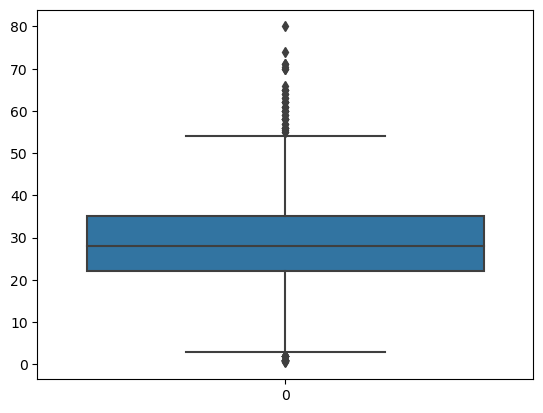

In [160]:
# Verificando outliers da coluna age por ter valores faltantes
sns.boxplot(data_titanic['age']);

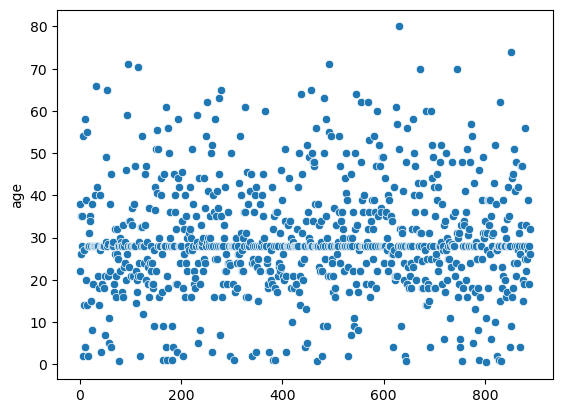

In [161]:
# verificando onde concentra-se boa parte das idades
sns.scatterplot(data_titanic['age']);

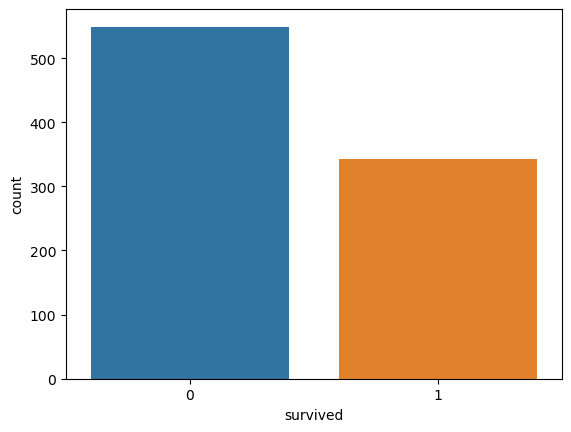

In [162]:
# checando sobrevivência
# 0 = Sobreviveu 1 = não sobreviveu
sns.countplot(data_titanic, x = data_titanic['survived']);

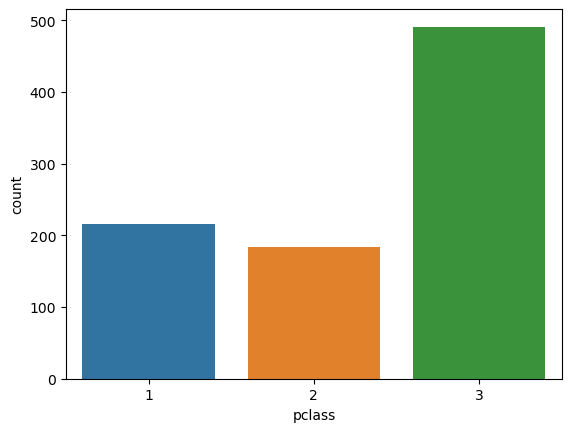

In [163]:
# checando classes que predominam
sns.countplot(data_titanic, x = data_titanic['pclass']);

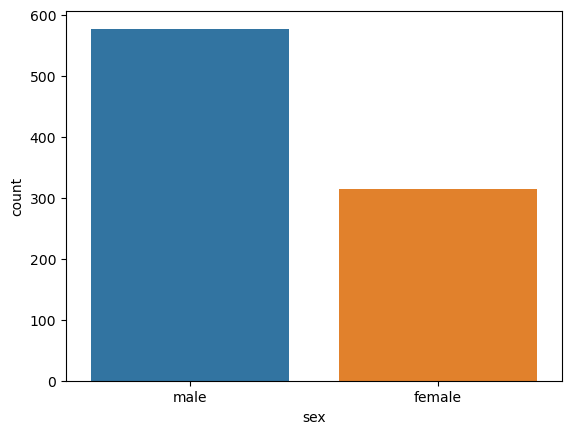

In [164]:
# checando sexo predominante
sns.countplot(data_titanic, x = data_titanic['sex']);

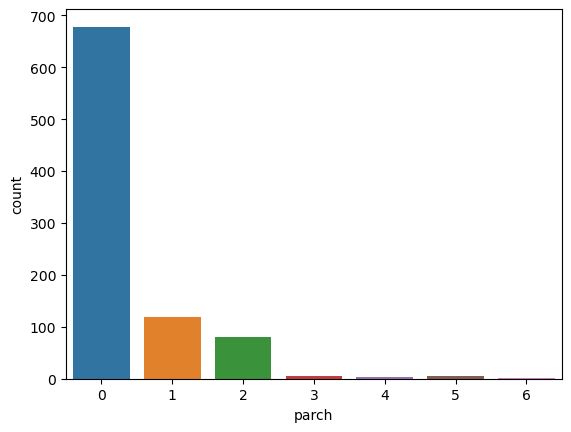

In [165]:
# checando parentescos
sns.countplot(data_titanic, x = data_titanic['parch']);

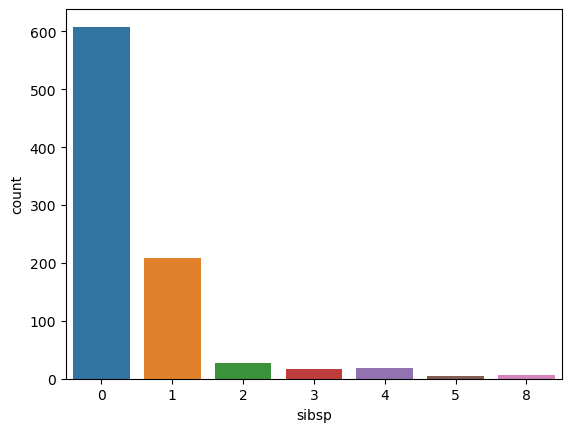

In [166]:
# checando familiares
sns.countplot(data_titanic, x = data_titanic['sibsp']);

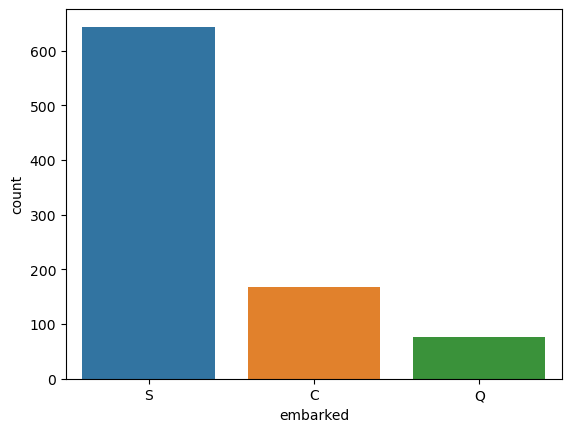

In [167]:
# cidade que predominou o embarque
sns.countplot(data_titanic, x = data_titanic['embarked']);

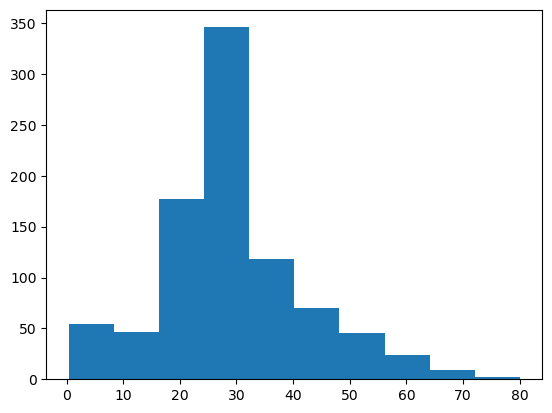

In [168]:
# checando a faixa etária presente no navio 
plt.hist(x = data_titanic['age']);

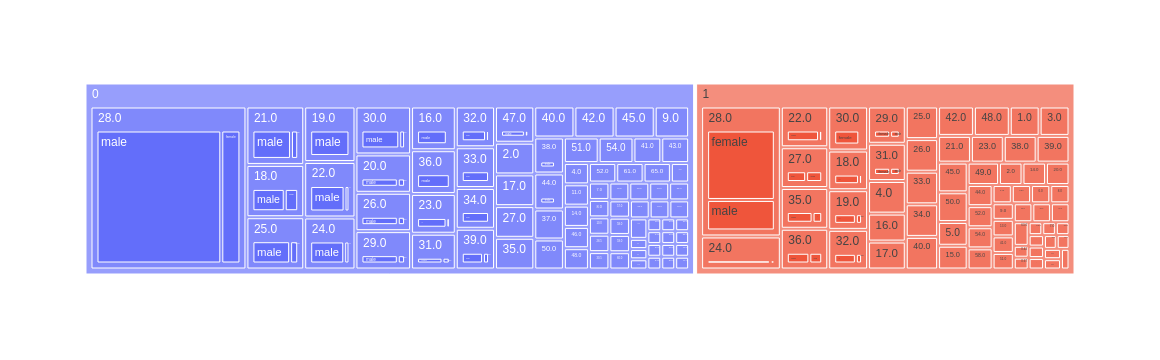

In [171]:
# tirando insights mesclando dois atributos com plots dinamicos

plot_dynamic = px.treemap(data_titanic, path=['survived','age', 'sex'])
plot_dynamic.show()

## Predictors and Classes

## Categoricals values treatments

## Data scaling

## Variables save